In [5]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.datasets import load_iris

# Step 2: Load Dataset (Iris dataset)
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Step 3: Apply Stratified Sampling
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in splitter.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

# Check the class distribution in both train and test datasets
print(f"Class distribution in training set:\n{y_train.value_counts(normalize=True)}")
print(f"Class distribution in test set:\n{y_test.value_counts(normalize=True)}")


Class distribution in training set:
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64
Class distribution in test set:
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64


In [1]:
import tkinter as tk
from tkinter import messagebox
import csv

class LabelingTool:
    def __init__(self, root, data_points):
        self.root = root
        self.data_points = data_points
        self.current_index = 0
        self.labels = {}

        self.root.title("Data Labeling Tool")

        # Display current data point with progress (e.g., X out of Y labeled)
        self.display_label = tk.Label(root, text=f"Data Point {self.current_index + 1}: {self.data_points[self.current_index]}")
        self.display_label.pack(pady=10)

        # Entry for label input
        self.label_entry = tk.Entry(root)
        self.label_entry.pack(pady=10)

        # Label progress
        self.progress_label = tk.Label(root, text=f"Labeled: {self.current_index}/{len(self.data_points)}")
        self.progress_label.pack(pady=10)

        # Next Button to proceed to the next data point
        self.next_button = tk.Button(root, text="Next", command=self.next_data_point)
        self.next_button.pack(pady=10)

    def next_data_point(self):
        label = self.label_entry.get()

        print(f"Label for current data point '{self.data_points[self.current_index]}': {label}")

        if label:
            self.labels[self.data_points[self.current_index]] = label
            self.label_entry.delete(0, tk.END)  # Clear the entry field after saving the label
        else:
            messagebox.showwarning("Warning", "Please enter a label before proceeding.")
            return

        self.current_index += 1
        if self.current_index < len(self.data_points):
            # Update the current data point and progress
            self.display_label.config(text=f"Data Point {self.current_index + 1}: {self.data_points[self.current_index]}")
            self.progress_label.config(text=f"Labeled: {self.current_index}/{len(self.data_points)}")
            print(f"Moved to next data point: {self.data_points[self.current_index]}")
        else:
            # If all data points are labeled, show a message and close the application
            messagebox.showinfo("Info", "All data points labeled!")
            print("All data points labeled. Saving labels to CSV.")
            self.save_labels_to_csv()  # Save labels to CSV file
            self.root.quit()

    def save_labels_to_csv(self):
        # Save labels to CSV file
        with open('labeled_data.csv', mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(['Data Point', 'Label'])  # Header
            for data_point, label in self.labels.items():
                writer.writerow([data_point, label])
        print("Labels saved to labeled_data.csv.")

if __name__ == "__main__":
    # Sample Data Points for labeling (keep it small for quick testing)
    data_points = ["Point 1", "Point 2", "Point 3", "Point 4", "Point 5"]

    # Initialize Tkinter
    root = tk.Tk()

    # Create and start the labeling tool
    tool = LabelingTool(root, data_points)
    root.mainloop()


Label for current data point 'Point 1': 1
Moved to next data point: Point 2
Label for current data point 'Point 2': 2
Moved to next data point: Point 3
Label for current data point 'Point 3': 3
Moved to next data point: Point 4
Label for current data point 'Point 4': 4
Moved to next data point: Point 5
Label for current data point 'Point 5': 5
All data points labeled. Saving labels to CSV.
Labels saved to labeled_data.csv.


In [2]:
from sklearn.model_selection import train_test_split

# Randomly sample 50% of the data
data_points = ["Point 1", "Point 2", "Point 3", "Point 4", "Point 5", "Point 6", "Point 7", "Point 8"]
train, _ = train_test_split(data_points, test_size=0.5, random_state=42)
print(f"Randomly sampled data points: {train}")


Randomly sampled data points: ['Point 3', 'Point 5', 'Point 4', 'Point 7']


In [3]:
def systematic_sampling(data_points, step=3):
    return data_points[::step]

data_points = ["Point 1", "Point 2", "Point 3", "Point 4", "Point 5", "Point 6", "Point 7", "Point 8"]
sampled_data = systematic_sampling(data_points, step=3)
print(f"Systematically sampled data points: {sampled_data}")


Systematically sampled data points: ['Point 1', 'Point 4', 'Point 7']


In [5]:
import random

def reservoir_sampling(stream, k):
    reservoir = []
    for i, data_point in enumerate(stream):
        if i < k:
            reservoir.append(data_point)
        else:
            # Randomly replace elements in the reservoir
            j = random.randint(0, i)
            if j < k:
                reservoir[j] = data_point
    return reservoir

# Simulating a stream of data points
stream = ["Point 1", "Point 2", "Point 3", "Point 4", "Point 5", "Point 6", "Point 7", "Point 8"]
sampled_points = reservoir_sampling(stream, 3)
print(f"Reservoir sampled data points: {sampled_points}")


Reservoir sampled data points: ['Point 8', 'Point 7', 'Point 3']


In [4]:
import random

# Example clusters of data points
clusters = {
    "Cluster 1": ["Point 1", "Point 2", "Point 3"],
    "Cluster 2": ["Point 4", "Point 5", "Point 6"],
    "Cluster 3": ["Point 7", "Point 8", "Point 9"]
}

# Select a random cluster
selected_cluster = random.choice(list(clusters.values()))
print(f"Cluster sampled data points: {selected_cluster}")


Cluster sampled data points: ['Point 7', 'Point 8', 'Point 9']


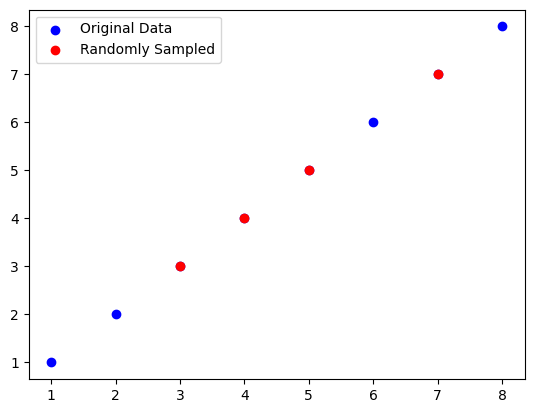

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (e.g., x and y coordinates)
data = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8]])

# Randomly sample 50% of the data
train, _ = train_test_split(data, test_size=0.5, random_state=42)

# Plot the data points
plt.scatter(data[:, 0], data[:, 1], c='blue', label='Original Data')
plt.scatter(train[:, 0], train[:, 1], c='red', label='Randomly Sampled')
plt.legend()
plt.show()



In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

# Example data with labels (for stratified sampling)
data_points = ["Point 1", "Point 2", "Point 3", "Point 4", "Point 5", "Point 6", "Point 7", "Point 8"]
labels = [0, 0, 1, 1, 2, 2, 0, 1]  # Grouping based on labels

# Stratified Sampling
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
for train_index, test_index in sss.split(data_points, labels):
    train_data = [data_points[i] for i in train_index]
    test_data = [data_points[i] for i in test_index]

# Plotting (just a conceptual plot, use actual data points instead)
print("Train:", train_data)
print("Test:", test_data)



Train: ['Point 6', 'Point 3', 'Point 4', 'Point 2']
Test: ['Point 1', 'Point 7', 'Point 5', 'Point 8']


In [9]:
import tkinter as tk

class LabelingTool:
    def __init__(self, root, data_points):
        self.root = root
        self.data_points = data_points
        self.current_index = 0
        self.labels = {}

        self.root.title("Data Labeling Tool")

        # Dropdown to choose sampling technique
        self.sampling_method_label = tk.Label(root, text="Choose Sampling Method")
        self.sampling_method_label.pack(pady=10)

        self.sampling_method = tk.StringVar(root)
        self.sampling_method.set("Random")  # default value

        self.sampling_methods = ["Random", "Stratified", "Systematic"]
        self.sampling_menu = tk.OptionMenu(root, self.sampling_method, *self.sampling_methods)
        self.sampling_menu.pack(pady=10)

        # Button to apply selected sampling method
        self.apply_button = tk.Button(root, text="Apply Sampling", command=self.apply_sampling)
        self.apply_button.pack(pady=10)

    def apply_sampling(self):
        method = self.sampling_method.get()
        print(f"Applying {method} sampling method.")
        if method == "Random":
            # Apply random sampling (example)
            print("Random sampling selected.")
        elif method == "Stratified":
            # Apply stratified sampling (example)
            print("Stratified sampling selected.")
        elif method == "Systematic":
            # Apply systematic sampling (example)
            print("Systematic sampling selected.")

    # Additional methods to handle labeling would follow...

# Tkinter root window
root = tk.Tk()
tool = LabelingTool(root, ["Point 1", "Point 2", "Point 3", "Point 4"])
root.mainloop()


Applying Random sampling method.
Random sampling selected.
Applying Stratified sampling method.
Stratified sampling selected.
Applying Systematic sampling method.
Systematic sampling selected.
